## **2. KLASYFIKACJA - WPROWADZENIE [5 MINUT]**

`**Klasyfikacja**` - do jakiej kategorii należy dana rzecz.

- mail → spam / nie spam
- zdjęcie → kot / pies
- komentarz → pozytywny / negatywny


`**Jak działa klasyfikacja?**`

Model dostaje dane treningowe, czyli przykłady z poprawnymi odpowiedziami np.:
  * ten mail to spam,
  * ten mail nie jest spamem,
  * to zdjęcie przedstawia kota,
  * to zdjęcie przedstawia psa.

Na tej podstawie model uczy się rozpoznawać wzorce i później próbuje klasyfikować nowe dane, których wcześniej nie widział.


| Regresja            | Klasyfikacja         |
| ------------------- | -------------------- |
| przewiduje liczby   | przewiduje kategorie |
| np. cena mieszkania | np. spam / nie spam  |
| np. temperatura     | np. kot / pies       |
| np. liczba punktów  | np. zdane / niezdane |


`**Gdzie używa się klasyfikacji?**`
- medycynie — chory / zdrowy,
- finansach — klient spłaci kredyt / nie spłaci,
- analizie tekstu — spam / nie spam, pozytywny / negatywny komentarz,
- analizie obrazu — rozpoznawanie twarzy, obiektów, znaków drogowych.


| Metoda                   | Krótko                                            |
| ------------------------ | ------------------------------------------------- |
| **Regresja logistyczna** | podaje prawdopodobieństwo przynależności do klasy |
| **Drzewa decyzyjne**     | działają jak seria pytań prowadzących do decyzji  |
| **k-NN**                 | sprawdza najbliższe podobne przykłady             |
| **SVM**                  | szuka granicy oddzielającej klasy                 |
| **Metoda Bayesa**        | wybiera najbardziej prawdopodobną klasę           |
| **Sieci neuronowe**      | rozpoznają złożone wzorce, np. obrazy i mowę      |



## REGRESJA LOGISTYCZNA

Stworzymy program wyznaczający szansę na przejście obby w zależności od
czasu poświęconego na trening.
Nasz program powinien:
  * Wygenerować cztery różne zestawy danych treningowych (czas, wynik = zdane/niezdane).
  * Dla każdego zestawu wytrenować model regresji logistycznej.
  * Narysować 4 osobne wykresy – na każdym punkty treningowe i dopasowana krzywa.
  * Na końcu narysować 5. wykres, który pokazuje wszystkie cztery krzywe razem, aby porównać, jak wyglądają różne modele.


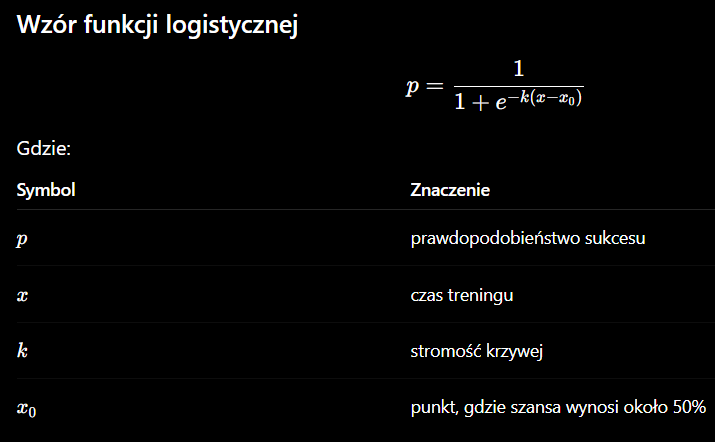

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [8]:
# Funkcja generuj_zbior(n, seed, k_true, x0_true) w której:
# - n – ile punktów danych wygenerować,
# - seed – ziarno losowania (dzięki temu zawsze mamy ten sam zestaw, jeśli użyjemy tego samego seed),
# - k_true – stromość krzywej (jak szybko szansa przejścia rośnie wraz z czasem),
# - x0_true – punkt, w którym szansa wynosi około 50%.
# Parametry k_true i x0_true są potrzebne do wyznaczenia krzywej regresji

def generuj_zbior(n, seed, k, x0):
  rng = np.random.default_rng(seed)

  # losujemy n wartosći czasu treningu (0 - 60 minut)
  czas = rng.uniform(0, 60, n) # x

  prawd = 1 / (1 + np.exp(-k * (czas - x0)))

  # Tutaj losujemy wynik dla każdej osoby:
  #   1 oznacza: zdał/przeszedł,
  #   0 oznacza: nie zdał/nie przeszedł.

  # Czyli jeśli ktoś ma prawdopodobieństwo 0.8, to ma dużą szansę dostać 1, ale nadal może czasem dostać 0.
  # To jest realistyczne, bo nawet ktoś dobrze przygotowany może nie zdać, a ktoś słabszy może mieć szczęście.
  wynik = rng.binomial(1, prawd)

  return czas, wynik

In [9]:
zbiory = [
    {"n":100, "seed":1, "k":0.2 , "x0":30, "etykieta":"Zbiór 1"},
    {"n":100, "seed":2, "k":0.15, "x0":25, "etykieta":"Zbiór 2"},
    {"n":100, "seed":3, "k":0.25, "x0":35, "etykieta":"Zbiór 3"},
    {"n":100, "seed":4, "k":0.1 , "x0":28, "etykieta":"Zbiór 4"}
]

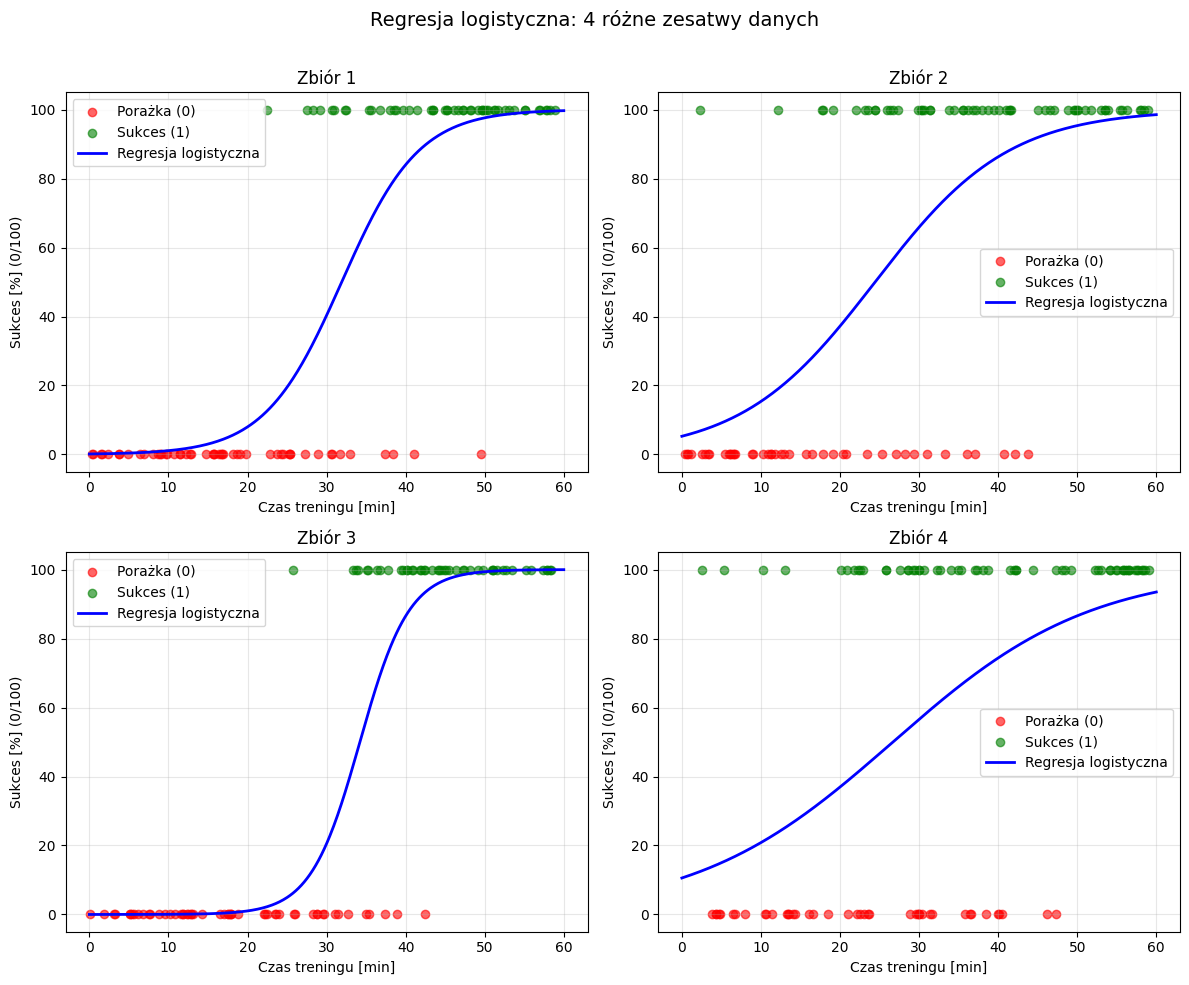

In [11]:
siatka = np.linspace(0, 60, 500).reshape(-1,1)

fig, axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.ravel()

krzywe = []

for i, zbior in enumerate(zbiory):
  # Dane
  czas, wynik = generuj_zbior(zbior["n"], zbior["seed"], zbior["k"], zbior["x0"])
  X = czas.reshape(-1, 1)

  # Model
  model = LogisticRegression()
  model.fit(X, wynik)

  # - X — czas treningu,
  # - wynik — odpowiedź: zdał/nie zdał.
  # Model próbuje znaleźć krzywą, która najlepiej oddziela osoby, które zdały, od tych, które nie zdały.

  ###
  przewidywania = model.predict_proba(siatka)[:, 1] * 100 # !!
  krzywe.append((przewidywania, zbior["etykieta"])) # !!
  ###

  axs[i].scatter(czas[wynik==0], wynik[wynik==0]*100, c="red", alpha=0.6, label="Porażka (0)")
  axs[i].scatter(czas[wynik==1], wynik[wynik==1]*100, c="green", alpha=0.6, label="Sukces (1)")

  # krzywa
  axs[i].plot(siatka, przewidywania, "b-", linewidth=2, label="Regresja logistyczna") # !!

  # Opisy
  axs[i].set_title(zbior["etykieta"])
  axs[i].set_xlabel("Czas treningu [min]")
  axs[i].set_ylabel("Sukces [%] (0/100)")
  axs[i].grid(True, alpha=0.3)
  axs[i].legend()

plt.suptitle("Regresja logistyczna: 4 różne zesatwy danych", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

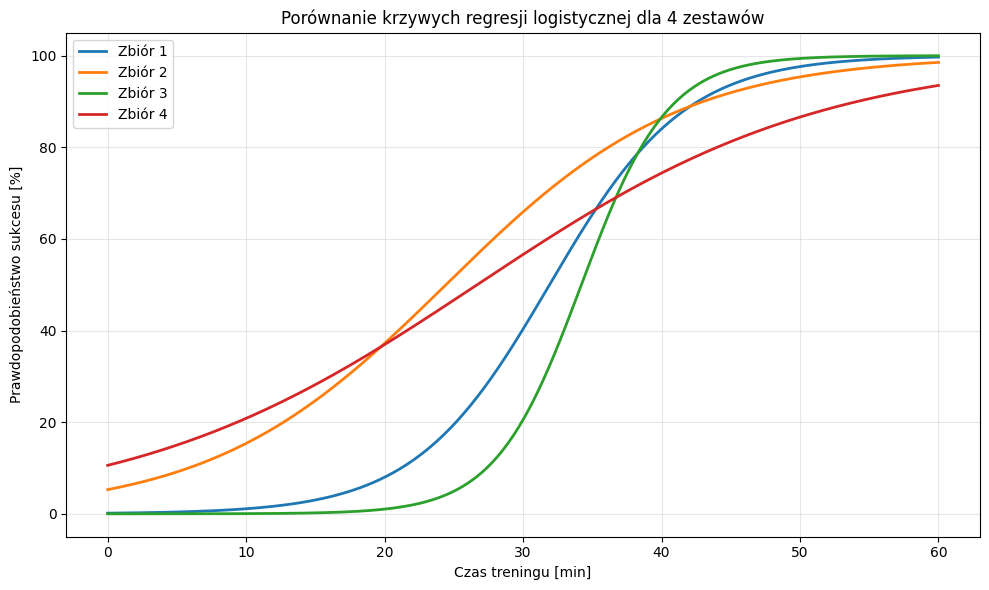

In [12]:
# ===== 5. wykres: wszystkie krzywe razem =====
plt.figure(figsize=(10, 6))
for przewidziane, etykieta in krzywe:
  plt.plot(siatka, przewidziane, linewidth=2, label=etykieta)

plt.xlabel("Czas treningu [min]")
plt.ylabel("Prawdopodobieństwo sukcesu [%]")
plt.title("Porównanie krzywych regresji logistycznej dla 4 zestawów")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()